# **Medical Condition Dataset**

---

| **Nama**  | Ridho Sulistiono |
|-----------|------------------|
| **NIM**   | 2304010035       |
| **Prodi** | D3 Statistika Terapan dan Komputasi |


### Deskripsi Dataset
Dataset **Used Car Prices in UK** merupakan kumpulan data otomotif yang komprehensif yang diperoleh dari platform marketplace kendaraan populer, yaitu *autotrader.co.uk*. Dataset ini terdiri dari 3.685 data, di mana setiap data merepresentasikan satu listing kendaraan yang unik, serta mencakup 13 fitur yang memberikan wawasan terkait karakteristik dan spesifikasi kendaraan.

Berikut adalah fitur yang terdapat dalam dataset:

- **title**: Nama dan merek kendaraan  
- **Price**: Harga kendaraan (dalam pound sterling)  
- **Mileage (miles)**: Jarak tempuh kendaraan  
- **Registration (year)**: Tahun registrasi kendaraan  
- **Previous Owners**: Jumlah pemilik sebelumnya  
- **Fuel Type**: Jenis bahan bakar  
- **Body Type**: Tipe bodi kendaraan  
- **Engine**: Spesifikasi mesin  
- **Gearbox**: Jenis transmisi  
- **Seats**: Jumlah kursi  
- **Doors**: Jumlah pintu  
- **Emission Class**: Kelas emisi kendaraan  
- **Service history**: Riwayat servis kendaraa


**Sumber** = https://www.kaggle.com/datasets/muhammadawaistayyab/used-cars-prices-in-uk/data

---

# 1. Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Digunakan untuk manipulasi data, visualisasi, dan preprocessing.

# 2. Load Data

Membaca file CSV kemudian melakukan pengecekan awal untuk memahami struktur data sebelum preprocessing

In [25]:
df = pd.read_csv("used_cars_UK.csv")
df.head()

,Unnamed: 0,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,0,SKODA Fabia,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,1,Vauxhall Corsa,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,2,Hyundai i30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,3,MINI Hatch,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,4,Vauxhall Corsa,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [26]:
# Cek dimensi dataset
df.shape


(3685, 14)

Dataset memiliki 3.685 baris dan 14 kolom

In [27]:
# ringkasan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3685 non-null   int64  
 1   title              3685 non-null   object 
 2   Price              3685 non-null   int64  
 3   Mileage(miles)     3685 non-null   int64  
 4   Registration_Year  3685 non-null   int64  
 5   Previous Owners    2276 non-null   float64
 6   Fuel type          3685 non-null   object 
 7   Body type          3685 non-null   object 
 8   Engine             3640 non-null   object 
 9   Gearbox            3685 non-null   object 
 10  Doors              3660 non-null   float64
 11  Seats              3650 non-null   float64
 12  Emission Class     3598 non-null   object 
 13  Service history    540 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 403.2+ KB


Ditemukan bahwa beberapa kolom memiliki missing values dengan jumlah yang cukup signifikan. Kolom *Service history* memiliki jumlah data yang jauh lebih sedikit dibandingkan total data, sehingga menunjukkan adanya missing values dalam jumlah besar. Selain itu, kolom *Previous Owners* juga memiliki missing value dalam jumlah yang cukup tinggi. Sementara itu, kolom *Engine*, *Doors*, *Seats*, dan *Emission Class* hanya memiliki missing value dalam jumlah yang relatif kecil. Selain itu, kolom *Unnamed: 0* merupakan indeks tambahan yang tidak memiliki makna analisis, sehingga dapat dipertimbangkan untuk dihapus pada tahap preprocessing.

In [28]:
# Statistik deskriptif kolom numerik
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,3685.0,2314.770963,1415.821308,0.0,1059.0,2279.0,3593.0,4727.0
Price,3685.0,5787.145726,4480.810572,400.0,2490.0,4000.0,7995.0,33900.0
Mileage(miles),3685.0,81328.164722,39420.833595,1.0,56984.0,80000.0,103000.0,1110100.0
Registration_Year,3685.0,2011.835007,5.092566,1953.0,2008.0,2012.0,2015.0,2023.0
Previous Owners,2276.0,2.807557,1.546028,1.0,2.0,3.0,4.0,9.0
Doors,3660.0,4.321038,0.986902,2.0,3.0,5.0,5.0,5.0
Seats,3650.0,4.900274,0.577200,2.0,5.0,5.0,5.0,7.0


Dari hasil statistik deskriptif, terlihat bahwa fitur numerik dalam dataset memiliki rentang nilai yang cukup bervariasi. Harga kendaraan (*Price*) berkisar antara 400 hingga 33.900 dengan rata-rata sekitar 5.787, yang menunjukkan adanya perbedaan harga yang cukup signifikan antar kendaraan.

Selain itu, jarak tempuh (*Mileage*) juga memiliki distribusi yang luas, dengan nilai maksimum mencapai lebih dari 1.100.000 miles, sehingga mengindikasikan kemungkinan adanya outlier dalam data. Tahun registrasi (*Registration_Year*) berada pada rentang 1953 hingga 2023 dengan rata-rata sekitar tahun 2011, yang menunjukkan bahwa dataset mencakup kendaraan dari berbagai generasi.

Sementara itu, jumlah pemilik sebelumnya (*Previous Owners*) memiliki rata-rata sekitar 2 hingga 3 pemilik dengan nilai maksimum mencapai 9. Fitur *Doors* dan *Seats* cenderung konsisten, di mana sebagian besar kendaraan memiliki 4–5 pintu dan sekitar 5 kursi.

In [29]:
# Cek missing values
df_temp_m = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Persentase (%)', ascending=False)

df_temp_m

,Jumlah Missing,Persentase (%)
Service history,3145,85.35
Previous Owners,1409,38.24
Emission Class,87,2.36
Engine,45,1.22
Seats,35,0.95
Doors,25,0.68
Registration_Year,0,0.00
Mileage(miles),0,0.00
Price,0,0.00
title,0,0.00


Terlihat bahwa terdapat perbedaan signifikan dalam jumlah missing values antar kolom.

- *Service history* memiliki missing value sangat tinggi (~85%)
- *Previous Owners* memiliki missing cukup besar (~38%)
- Kolom *Emission Class, Engine, Seats, Doors* relatif kecil (<3%)
- Kolom lainnya tidak memiliki missing value


In [30]:
# Cek duplikasi data
df.duplicated().sum()

np.int64(0)

Tidak ditemukan data duplikat dalam dataset

In [31]:
# Cek unique values pada kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns

summary = []

for col in cat_cols:
    unique_vals = df[col].dropna().unique().tolist()
    
    if len(unique_vals) > 5:
        sample = ", ".join(map(str, unique_vals[:3])) + ", ..."
    else:
        sample = ", ".join(map(str, unique_vals))
    
    summary.append({
        'Fitur': col,
        'Jumlah Kategori': len(unique_vals),
        'Deskripsi': sample
    })

unique_summary = pd.DataFrame(summary).sort_values('Jumlah Kategori', ascending=False)

unique_summary

,Fitur,Jumlah Kategori,Deskripsi
0,title,469,"SKODA Fabia, Vauxhall Corsa, Hyundai i30, ..."
3,Engine,34,"1.4L, 1.2L, 1.3L, ..."
2,Body type,10,"Hatchback, Coupe, Estate, ..."
1,Fuel type,6,"Diesel, Petrol, Petrol Plug-in Hybrid, ..."
5,Emission Class,6,"Euro 6, Euro 4, Euro 5, ..."
4,Gearbox,2,"Manual, Automatic"
6,Service history,1,Full


# 3. Preprocessing

Tahapan preprocessing yang dilakukan meliputi:

- Melakukan duplikasi dataset untuk menjaga data asli tetap utuh  
- Menghapus kolom yang tidak relevan terhadap analisis  
- Menangani missing values pada beberapa fitur  
- Melakukan feature engineering sederhana untuk meningkatkan representasi data  
- Mendeteksi dan menangani outlier menggunakan metode IQR  
- Melakukan encoding pada variabel kategorikal  
- Membagi data menjadi data training dan testing  
- Melakukan feature scaling menggunakan StandardScaler  

## 3.1 Salin Data

Menyalin dataset dilakukan untuk menjaga data asli tetap utuh sebagai referensi. Dengan demikian, setiap proses preprocessing dilakukan pada salinan data sehingga tidak memengaruhi data mentah.

In [32]:
df_p = df.copy()

## 3.2 Menghapus Kolom Tidak Relevan

Beberapa kolom yang tidak memiliki kontribusi terhadap analisis dihapus dari dataset. Kolom seperti *Unnamed: 0* merupakan indeks tambahan

In [33]:
df_p = df_p.drop(columns=['Unnamed: 0'])
df_p.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA Fabia,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,Vauxhall Corsa,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,Hyundai i30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI Hatch,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,Vauxhall Corsa,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


## 3.3 Penanganan Missing Values

Penanganan missing values dilakukan dengan pendekatan yang berbeda berdasarkan tingkat kehilangan data pada masing-masing kolom.

- Kolom *Service history* dihapus karena memiliki jumlah missing value yang sangat besar, sehingga tidak representatif untuk dianalisis. 

- Sementara itu, kolom numerik seperti *Previous Owners*, *Doors*, dan *Seats* diisi menggunakan nilai median untuk menjaga distribusi data. 

- Untuk kolom kategorikal seperti *Engine* dan *Emission Class*, missing value diisi menggunakan nilai modus (nilai yang paling sering muncul).

Pendekatan ini dilakukan untuk mempertahankan sebanyak mungkin data tanpa mengurangi kualitas informasi.

In [34]:
# drop kolom service historu
df_p = df_p.drop(columns=['Service history'])

# fill missing values pada kolom numerik dengan median
num_cols = ['Previous Owners', 'Doors', 'Seats']

for col in num_cols:
    df_p[col] = df_p[col].fillna(df_p[col].median())

# fill missing values pada kolom kategorikal dengan modus
df_p['Engine'] = df_p['Engine'].fillna(df_p['Engine'].mode()[0])
df_p['Emission Class'] = df_p['Emission Class'].fillna(df_p['Emission Class'].mode()[0])

df_p.isnull().sum()

title                0
Price                0
Mileage(miles)       0
Registration_Year    0
Previous Owners      0
Fuel type            0
Body type            0
Engine               0
Gearbox              0
Doors                0
Seats                0
Emission Class       0
dtype: int64

## 3.4 Feature Engineering

In [35]:
# konversi kolom Engine ke tipe numerik
df_p['Engine'] = df_p['Engine'].str.replace('L', '').str.strip().astype(float)
df_p['Engine'].head()

0    1.4
1    1.2
2    1.4
3    1.4
4    1.3
Name: Engine, dtype: float64

Fitur *Engine* dikonversi dari format teks menjadi numerik dengan menghilangkan satuan liter (L) dan mengambil nilai angkanya. 

Transformasi ini dilakukan karena kapasitas mesin memiliki makna kuantitatif yang lebih relevan untuk analisis dibandingkan diperlakukan sebagai variabel kategorikal.

In [36]:
# umur kendaraan
df_p['car_age'] = 2024 - df_p['Registration_Year']

df_p[['Registration_Year', 'car_age']].sample(5)

,Registration_Year,car_age
1532,2009,15
2493,2015,9
237,2008,16
583,2016,8
2908,2021,3


Fitur *car_age* dibuat berdasarkan selisih antara tahun referensi dataset dengan tahun registrasi kendaraan. Fitur ini memberikan informasi yang lebih relevan dibandingkan hanya menggunakan tahun registrasi, karena umur kendaraan lebih berpengaruh dalam analisis harga.

In [37]:
df_p['Brand'] = df_p['title'].str.split().str[0].str.upper()
df_p[['title', 'Brand']].sample(5)

,title,Brand
1695,Fiat 500,FIAT
1859,Audi A3,AUDI
2948,Ford Fiesta,FORD
590,Vauxhall Zafira,VAUXHALL
1706,Nissan Juke,NISSAN


Ditambahkan fitur *Brand* yang diekstrak dari kolom *title* dengan mengambil kata pertama dari deskripsi kendaraan. Fitur ini bertujuan untuk menangkap informasi merek kendaraan yang memiliki pengaruh terhadap harga dan karakteristik mobil.

## 3.5 Deteksi dan Penanganan Outlier



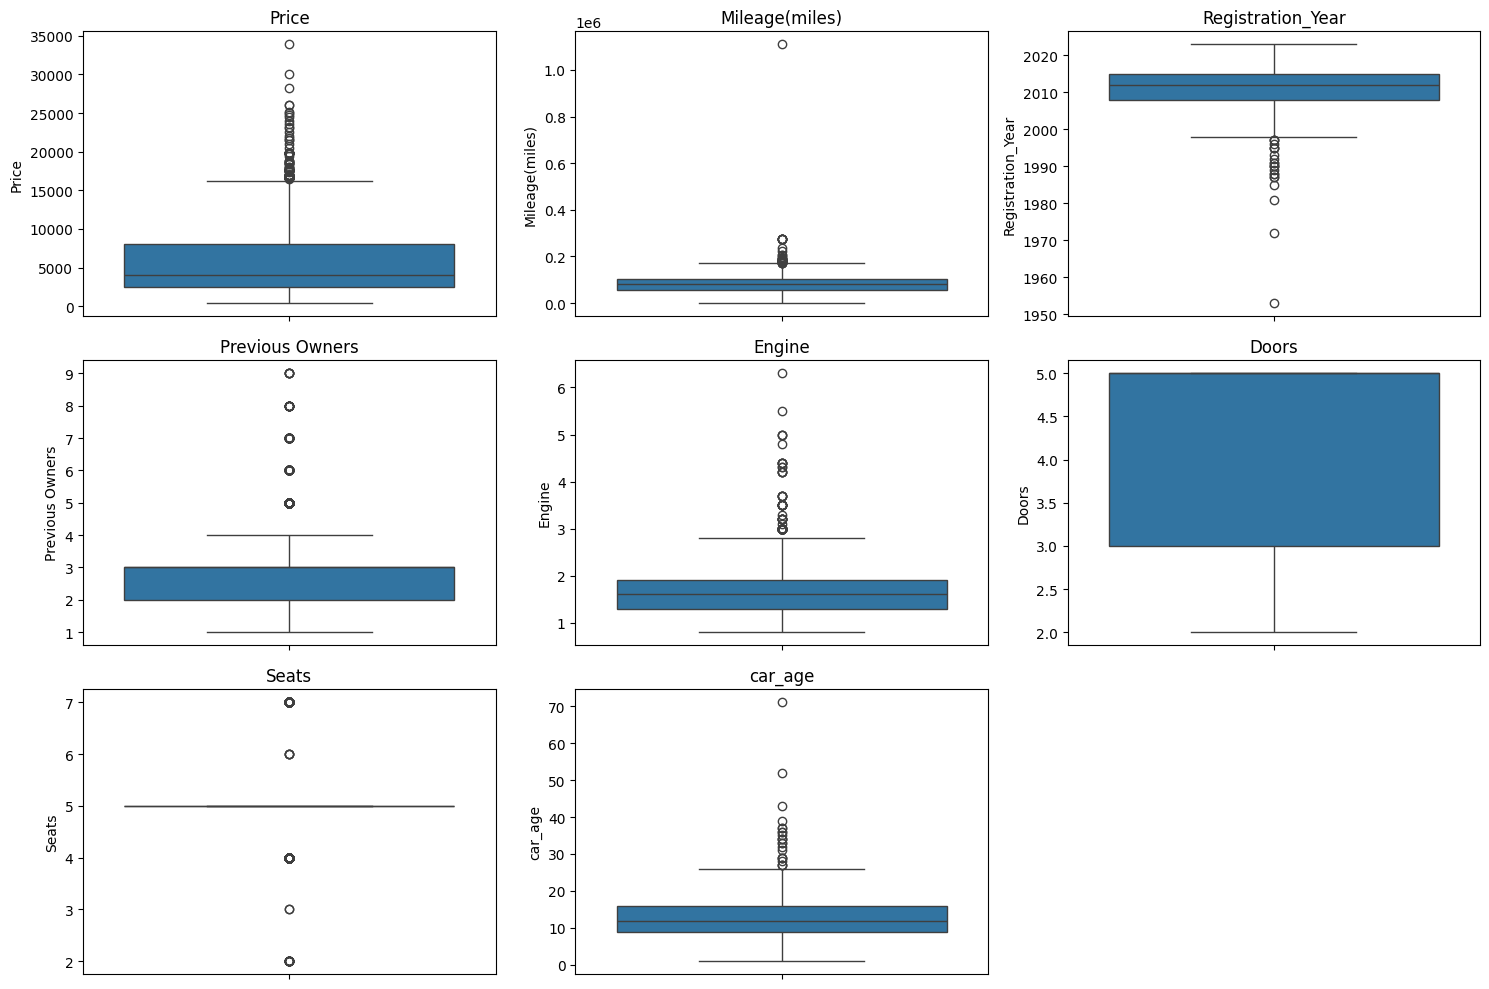

In [38]:
num_cols = df_p.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_p[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [39]:
extremes = pd.DataFrame({
    'Price_min': df_p.loc[df_p['Price'].idxmin()],
    'Price_max': df_p.loc[df_p['Price'].idxmax()],
    'Mileage_min': df_p.loc[df_p['Mileage(miles)'].idxmin()],
    'Mileage_max': df_p.loc[df_p['Mileage(miles)'].idxmax()]
})

extremes

,Price_min,Price_max,Mileage_min,Mileage_max
title,SEAT Ibiza,Mercedes-Benz GLE Class,MG MG ZS,Volkswagen Beetle
Price,400,33900,18365,2495
Mileage(miles),120842,92000,1,1110100
Registration_Year,2010,2019,2023,2003
Previous Owners,4.0,1.0,3.0,4.0
Fuel type,Diesel,Diesel,Petrol,Petrol
Body type,Hatchback,SUV,SUV,Hatchback
Engine,1.2,2.0,1.5,2.0
Gearbox,Manual,Automatic,Manual,Automatic
Doors,3.0,5.0,5.0,3.0


Outlier pada fitur *Mileage(miles)* ditangani karena terdapat nilai ekstrem yang jauh di luar distribusi normal dan berpotensi memengaruhi analisis.

Sementara itu, outlier pada fitur *Price* tidak dihapus karena variasi harga masih merepresentasikan kondisi nyata yang dipengaruhi oleh perbedaan merek dan spesifikasi kendaraan.

In [40]:
outlier_report = []

col = 'Mileage(miles)'

Q1  = df_p[col].quantile(0.25)
Q3  = df_p[col].quantile(0.75)
IQR = Q3 - Q1

lower = max(1, Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR

n_out = ((df_p[col] < lower) | (df_p[col] > upper)).sum()

# winsorizing
df_p[col] = df_p[col].clip(lower=lower, upper=upper)

outlier_report.append({
    'Kolom': col,
    'Outlier Ditangani': n_out,
    'Batas Bawah': round(lower,2),
    'Batas Atas': round(upper,2)
})

report_df = pd.DataFrame(outlier_report)

print(report_df)

            Kolom  Outlier Ditangani  Batas Bawah  Batas Atas
0  Mileage(miles)                 34            1    172024.0


Penanganan outlier pada fitur *Mileage(miles)* dilakukan menggunakan metode winsorizing berbasis IQR. 

Hasil perhitungan menunjukkan bahwa terdapat 34 data yang berada di luar batas yang ditentukan. Nilai tersebut kemudian disesuaikan ke dalam rentang batas bawah dan batas atas tanpa menghapus data.

Pendekatan ini dipilih untuk menjaga jumlah data tetap utuh sekaligus mengurangi pengaruh nilai ekstrem terhadap analisis.

## 3.5 Encoding Kolom Kategorikal

Fitur kategorikal dikonversi menjadi bentuk numerik agar dapat digunakan dalam proses analisis dan pemodelan. Metode yang digunakan adalah *one-hot encoding*. Metode ini dipilih karena variabel kategorikal dalam dataset tidak memiliki hubungan urutan antar kategori. Dengan demikian, *one-hot encoding* mampu merepresentasikan setiap kategori secara independen tanpa mengasumsikan hubungan numerik yang tidak relevan.

In [41]:
df_p = df_p.drop(columns=['title'], errors='ignore')

In [42]:
cat_cols = ['Brand', 'Fuel type', 'Body type', 'Gearbox', 'Emission Class']
df_p = pd.get_dummies(df_p, columns=cat_cols, drop_first=True)
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 75 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            3685 non-null   int64  
 1   Mileage(miles)                   3685 non-null   int64  
 2   Registration_Year                3685 non-null   int64  
 3   Previous Owners                  3685 non-null   float64
 4   Engine                           3685 non-null   float64
 5   Doors                            3685 non-null   float64
 6   Seats                            3685 non-null   float64
 7   car_age                          3685 non-null   int64  
 8   Brand_ALFA                       3685 non-null   bool   
 9   Brand_AUDI                       3685 non-null   bool   
 10  Brand_BMW                        3685 non-null   bool   
 11  Brand_CHEVROLET                  3685 non-null   bool   
 12  Brand_CHRYSLER      

## 3.6 Simpan Data

Dataset hasil preprocessing disalin ke dalam variabel baru untuk menjaga konsistensi data akhir. Selanjutnya, dataset tersebut disimpan dalam format CSV sebagai dataset bersih yang siap digunakan pada tahap analisis dan pemodelan.

In [43]:
df_clean = df_p.copy()
df_clean.to_csv('used_cars_clean.csv', index=False)

## 3.7 Membagi Data


Setelah dataset hasil preprocessing disimpan, dilakukan pembagian data menjadi data training dan testing dengan rasio 80:20. Pembagian ini bertujuan untuk melatih model menggunakan data training serta mengevaluasi performa model pada data testing.

In [44]:
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (2948, 74)
Test : (737, 74)


 Hasil pembagian menghasilkan 2.948 data training dan 737 data testing. Jumlah fitur yang digunakan dalam model sebanyak 74 fitur setelah dilakukan preprocessing dan encoding.

## 3.8 Scaling data

Feature scaling dilakukan karena setiap fitur dalam dataset memiliki rentang nilai yang berbeda-beda. Sebagai contoh, fitur seperti *Mileage(miles)* dapat memiliki nilai hingga ratusan ribu, sementara fitur lain seperti *Engine* atau *Doors* memiliki rentang yang jauh lebih kecil.

Perbedaan skala ini dapat memengaruhi performa model, terutama pada algoritma berbasis jarak seperti K-Nearest Neighbors atau model berbasis gradien seperti Linear Regression, di mana fitur dengan skala lebih besar dapat mendominasi proses pembelajaran.

Untuk mengatasi hal tersebut, digunakan metode StandardScaler yang menstandardisasi setiap fitur sehingga memiliki nilai rata-rata (mean) sebesar 0 dan standar deviasi (std) sebesar 1. Dengan demikian, seluruh fitur berada pada skala yang sebanding.

Proses scaling dilakukan dengan cara melakukan *fit* pada data training dan *transform* pada data testing. Hal ini penting untuk menghindari data leakage, yaitu kondisi di mana informasi dari data testing ikut memengaruhi proses pelatihan model.

In [45]:
num_cols = ['Mileage(miles)', 'Registration_Year', 'Previous Owners',
            'Engine', 'Doors', 'Seats', 'car_age']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [48]:
X_train.sample(5)

,Mileage(miles),Registration_Year,Previous Owners,Engine,Doors,Seats,car_age,Brand_ALFA,Brand_AUDI,Brand_BMW,...,Body type_Minibus,Body type_Pickup,Body type_SUV,Body type_Saloon,Gearbox_Manual,Emission Class_Euro 2,Emission Class_Euro 3,Emission Class_Euro 4,Emission Class_Euro 5,Emission Class_Euro 6
1874,0.363505,-1.335771,0.101964,0.810111,-1.341851,-1.555047,1.335771,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1230,1.176723,-0.364517,-0.719323,-0.013977,0.686232,0.164487,0.364517,False,False,False,...,False,False,True,False,True,False,False,True,False,False
2032,-0.073878,-0.558768,3.387114,-0.426021,0.686232,0.164487,0.558768,False,False,False,...,False,False,False,False,True,False,False,True,False,False
989,-0.877752,0.800988,0.101964,-0.013977,0.686232,0.164487,-0.800988,False,False,False,...,False,False,True,False,True,False,False,False,False,True
2339,0.992771,0.995239,-1.540610,-0.013977,0.686232,0.164487,-0.995239,False,False,False,...,False,False,False,False,True,False,False,False,False,True


Feature scaling hanya diterapkan pada fitur numerik, sementara fitur hasil encoding (*dummy variables*) tidak dilakukan scaling karena telah berada dalam skala yang seragam (0 dan 1). Hal ini dilakukan untuk menjaga interpretasi data tetap jelas dan menghindari distorsi nilai pada fitur kategorikal.